# Human in the loop

그래프 중간 과정에서 사용자의 응답을 요청하는 방식
- `interrupt` : 해당 시점에 실행을 중단함
- `Command(resume)` : 재개할 때에는 `Command(resume)` 을 사용
- `Command(goto)` : 다른 위치로 이동 시에 사용

## 환경설정 및 Jupyter 설치
### 가상환경 세팅
```bash
conda create --name env-langgraph-fc python=3.10 -y
```
<br/>

### 세팅 확인
가상환경 디렉터리 확인
```bash
ls -al ~/miniforge3/envs/env-langgraph-fc 
```
<br/>

가상환경 활성화
```bash
conda activate env-langgraph-fc
```
<br/>

가상환경을 끌때는 다음과 같이 한다.
```bash
conda deactivate
```
<br/>

### 의존성 설정
먼저 jupyter 설치
```bash
# pip 대신 mamba를 사용하면 패키지 설치 속도가 훨씬 빠릅니다.
mamba install -c conda-forge jupyter notebook ipykernel -y
```
<br/>

다음 의존성 설치
```bash
## pip 를 이용해 설치
!pip install langgraph langchain langchain_google_genai langchain_community

## 또는 mamba 를 이용해 설치
mamba install langgraph langchain langchain_google_genai langchain_community
```
<br/>

keyring 라이브러리 설치
```bash
## pip 을 이용해 설치
pip install keyring

## 또는 mamba 를 이용해 keyring 설치
mamba install keyring
```
<br/>

## keyring import (api key 설정)
- (1) 미리 터미널에 입력해둔다.
- (2) python 코드 내에서 사용한다.

```bash
## bash 쉘 에서 다음 내용을 입력
## 형식 keyring set {{서비스명}} {{계정명}}

## e.g.
keyring set gemini-api-key---alpha300uk alpha300uk  
Password for 'alpha300uk' in 'gemini-api-key---alpha300uk':
```

In [6]:
import keyring
gemini_service_name = "gemini-api-key---alpha300uk"
gemini_username = "alpha300uk"
gemini_api_token = keyring.get_password(gemini_service_name, gemini_username)

tavily_service_name = "tavily-api-key---alpha300uk"
tavily_username = "alpha300uk"
taviliy_api_token = keyring.get_password(tavily_service_name, tavily_username)

langsmith_service_name = "langsmith-api-key---alpha300uk"
langsmith_username = "alpha300uk"
langsmith_api_token = keyring.get_password(langsmith_service_name, langsmith_username)

## 의존성 설치 (혹시 설치 안했을 경우를 위해 추가한 섹션)

In [12]:
!pip install langgraph langchain langchain_google_genai langchain-tavily rich -q
### ! pip install langgraph langchain langchain_google_genai langchain_community

## llm, ratelimiter 선언

In [4]:
## llm, ratelimiter 선언
import os
os.environ['GOOGLE_API_KEY'] = gemini_api_token

from langchain_core.rate_limiters import InMemoryRateLimiter
from langchain_google_genai import ChatGoogleGenerativeAI

# Gemini API는 분당 10개 요청으로 제한
# 즉, 초당 약 0.167개 요청 (10/60)
rate_limiter = InMemoryRateLimiter(
    # requests_per_second=0.167,  # 분당 10개 요청
    requests_per_second=1,  # 초당 최대 1개, 분당 최대 60개 요청
    check_every_n_seconds=0.1,  # 100ms마다 체크
    max_bucket_size=10,  # 최대 버스트 크기
)

# rate limiter를 LLM에 적용
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    rate_limiter=rate_limiter,
    # temperature
    # max_tokens

    thinking_budget = 500  # 추론(Reasoning) 토큰 길이 제한
)

## API key 세팅

In [7]:
os.environ['LANGCHAIN_API_KEY'] = langsmith_api_token
os.environ['LANGCHAIN_PROJECT'] = 'LangGraph_FastCampus'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_TRACING_V2']='true'

## 네이버 블로그 검색 tool 구성
네이버의 검색 API를 이용해, 블로그 검색을 연결하겠습니다.   
(https://developers.naver.com/apps/#/register?defaultScope=search)

In [ ]:
import os
import sys
import urllib.request
import json
from langchain_core.tools import tool

from typing_extensions import TypedDict, Literal, Annotated

headers = {
    'X-Naver-Client-Id': 'Ko6yIqbV2TOHq9rPH8tu',
    'X-Naver-Client-Secret': 'BvqX8mNtHu'
}

@tool
def search_blogs(query: str, display : int = 10, sort : Literal['sim', 'date'] = 'sim') -> list:
    """네이버 블로그 검색을 수행하여 검색 결과를 리스트로 반환합니다.
    query: 검색어
    display: 검색 결과 개수
    sort: sim(관련도순), date(시간순)
    """

    client_id = headers['X-Naver-Client-Id']
    client_secret = headers['X-Naver-Client-Secret']

    encText = urllib.parse.quote(query)
    url = f"https://openapi.naver.com/v1/search/blog?query={encText}&display={display}"

    request = urllib.request.Request(url)
    request.add_header("X-Naver-Client-Id", client_id)
    request.add_header("X-Naver-Client-Secret", client_secret)

    response = urllib.request.urlopen(request)
    rescode = response.getcode()

    if rescode == 200:
        response_body = response.read()
        data = json.loads(response_body.decode('utf-8'))

        # 필요한 데이터 추출
        blog_list = [
            {
                "title": item["title"].replace("<b>", "").replace("</b>", ""),  # 태그 제거
                "link": item["link"],
                "description": item["description"].replace("<b>", "").replace("</b>", ""),
                "postdate": item["postdate"]
            }
            for item in data.get("items", [])
        ]

        return blog_list
    else:
        return ['에러 발생, 다른 검색어로 다시 시도하세요.']


tool_list = [search_blogs]
llm_with_tools = llm.bind_tools(tool_list)

llm_with_tools.invoke("안녕")

AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d2ddb-ab86-7062-8579-b0dad96be903-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 118, 'output_tokens': 8, 'total_tokens': 126, 'input_token_details': {'cache_read': 0}})

### 1. 도구 정의 및 바인딩 테스트

그래프를 본격적으로 구성하기에 앞서, **LLM이 도구 목록을 정확히 인식하고 호출할 수 있는지**를 확인하는 단계입니다.

- **`tool_list = [search_blogs]`**: 에이전트가 사용할 수 있는 도구들을 정의합니다.
- **`llm_with_tools = llm.bind_tools(tool_list)`**: 
    - 정의된 `tool_list` 안의 도구 설명(Docstring)과 파라미터 정보를 LLM에게 함께 전달합니다. 
    - 이로써 LLM은 해당 도구들을 언제 써야 할지 알 수 있는 상태가 됩니다.
- **`llm_with_tools.invoke("안녕")`**: 
    - LLM에게 실제 메시지를 던져 **도구 호출이 일어나는지(Tool Call 발생 여부)**를 테스트합니다. 
    - "안녕"과 같은 일반적인 인사는 도구 호출 없이 일반 텍스트가 반환되는 것이 정상입니다.

> [!NOTE]
> 이 코드는 그래프 실행(`graph.invoke`)이 아닌, **LLM 모델이 도구 요청 형식을 갖추었는지를 확인하는 단독 호출**입니다.


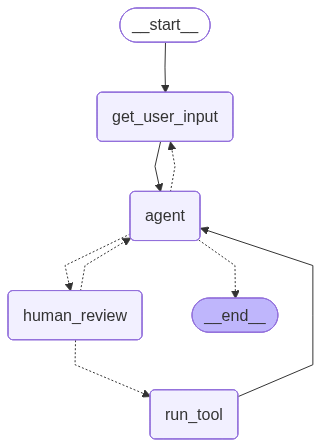

In [ ]:
### 자료구조 선언 및 정의
from langgraph.graph.message import add_messages

# query와 messages를 저장
class State(TypedDict):
    query : str
    messages : Annotated[list, add_messages]


### 
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage


# 메시지 입력
def get_user_input(state):
    human_message = input()
    return {'messages':[HumanMessage(content = human_message)]}


def agent(state):
    system_message = SystemMessage(content='''당신은 검색 및 요약 챗봇입니다.
사용자의 질문을 해결하기 위해 검색 툴을 사용하고, 해당 결과를 바탕으로 답변하세요.
요청을 해결한 다음에는 마지막에 '감사합니다! 챗봇을 종료합니다!'를 출력하세요.''')

    return {"messages": [llm_with_tools.invoke([system_message] + state["messages"])]}


def run_tool(state):
    new_messages = []
    last_message = state["messages"][-1]

    tools = {tool.name:tool for tool in tool_list}

    tool_calls = last_message.tool_calls

    for tool_call in tool_calls:
        tool = tools[tool_call["name"]]
        result = tool.invoke(tool_call)
        # ToolMessage
        new_messages.append(result)
    return {"messages": new_messages}


### Human Review
# Typing Hint를 연결하면 Graph에 표시됨
def human_review(state) -> Command[Literal["agent", "run_tool"]]:

    # !!중요!!
    # Human_review가 실행되는 상황은 언제일까요?
    # Tool을 실행하기 전이므로, 이 상태의 Context는
    # 항상 [..., AIMessage(content, tool_calls)]

    last_message = state["messages"][-1] # tool call 포함된 AIMessage
    tool_call = last_message.tool_calls[-1]

    # inturrupt로 중단된 결과는 Command를 통해 재개
    human_review = interrupt(
        {
            "question": "이대로 진행할까요?",
            "tool_call": tool_call,
        }
    )
    review_action = human_review["action"]
    review_data = human_review.get("data")

    print('Decision:', review_action, '\n Content:', review_data)


    # 그대로 진행하는 경우, run_tool로 진입
    if review_action == "continue":
        return Command(goto="run_tool")

    # update가 필요한 경우, review_data를 args에 넣고 run_tool로 진입
    elif review_action == "update":
        updated_message = {
            "role": "ai",
            "content": last_message.content,
            "tool_calls": [
                {
                    "id": tool_call["id"],
                    "name": tool_call["name"],

                    "args": review_data,
                    # 새로운 입력
                }
            ],
            "id": last_message.id,
            # 메시지 id를 동일하게 설정해 Override
        }
        return Command(goto="run_tool", update={"messages": [updated_message]})


    # Feedback: 단순 언어로 피드백을 전달하고 싶은 경우
    elif review_action == "feedback":

        # Tool Call 요청을 새로운 유저 메시지로 대체합니다.

        new_human_message = HumanMessage(content = review_data,
        id = last_message.id)

        return Command(goto="agent", update={"messages": [new_human_message]})


def route_after_llm(state) -> Literal[END, "get_user_input", "human_review"]:

    last_message = state['messages'][-1]
    # 마지막 메시지: tool calling
    # 2025.10.26 업데이트: Gemini의 Thinking 모델(2.5 이후)에는
    # Tool Calling 이후의 messages에 signature가 포함되어 형식이 달라집니다.
    last_message_content = last_message.content

    if not last_message.tool_calls:
        if '감사합니다! 챗봇을 종료합니다!' in last_message_content:
            return END
        elif isinstance(last_message_content[0], dict) and 'text' in last_message_content[0] and '감사합니다! 챗봇을 종료합니다!' in last_message_content[0]['text']:
            return END
        return 'get_user_input'
    else:
        return "human_review"


builder = StateGraph(State)
builder.add_node(get_user_input)
builder.add_node(agent)
builder.add_node(run_tool)
builder.add_node(human_review)

builder.add_edge(START, "get_user_input")
builder.add_edge('get_user_input', "agent")
builder.add_conditional_edges("agent", route_after_llm)
builder.add_edge("run_tool", "agent")

memory = MemorySaver()

graph = builder.compile(checkpointer=memory)
# 중간 상태 저장을 위해 체크포인터가 필요합니다!
graph

### Human-in-the-loop (에이전트 제어 및 승인)

이 워크플로우는 에이전트가 도구(Tool)를 실행하기 직전에 **사람의 승인을 받거나 인자값을 수정**할 수 있는 강력한 제어 기능을 제공합니다.

#### 1. 핵심 노드 설명
- **`get_user_input`**: 사용자로부터 초기 질문이나 추가 피드백을 직접 입력받습니다.
- **`agent`**: 질문을 분석하고, 필요한 도구가 있다면 호출(`tool_calls`)을 시도합니다.
- **`human_review` (HITL의 핵심)**:
    - **`interrupt`**: 도구 호출 시점에 그래프 실행을 **일시 중지**하고 사용자의 응답을 기다립니다.
    - **`Command`**: 사람의 판단(`continue`, `update`, `feedback`)에 따라 다음 경로를 결정합니다.
        - **승인(`continue`)**: 그대로 도구 실행(`run_tool`) 노드로 이동.
        - **수정(`update`)**: 사람의 수정된 인자값으로 도구를 실행.
        - **피드백(`feedback`)**: 도구 호출 대신 사람의 의견을 다시 에이전트에게 전달.

#### 2. 흐름 제어(`route_after_llm`) 및 분기 원리
에이전트(LLM)가 응답한 **`AIMessage`**의 구조를 분석하여 다음과 같이 경로를 결정합니다.

- **`if last_message.tool_calls` (도구 호출이 있는 경우)**: 
    - **사람의 검토(`human_review`)** 노드로 이동하여 도구 실행 전 확인을 거칩니다.

- **`if not last_message.tool_calls` (도구 호출이 없는 경우 - 일반 텍스트 답변)**: 
    - **작별 인사를 한 경우**: "감사합니다!..." 문구가 답변에 포함되어 있다면 **`END`**로 종료합니다.
    - **일반 답변인 경우**: 추가 대화를 이어가기 위해 다시 **`get_user_input`** 단계로 되돌아갑니다. (멀티턴 대화 유지)

#### 3. 체크포인트의 역할 (`MemorySaver`)
- `interrupt`로 중단된 시점의 내부 상태(State)와 도구 호출 정보를 복구하기 위해 **체크포인터가 반드시 필요**합니다.
- `builder.compile(checkpointer=memory)` 설정을 통해 중단된 지점부터 다시 시작할 수 있는 안정적인 환경을 구축합니다.

---

#### 실행 흐름 요약
1.  **시작** → 질문 입력 → **에이전트 판단** 
2.  **판단 결과가 `AIMessage(tool_calls=...)`일 때**: 
    - **사람의 검토(`interrupt`)** → [승인/수정] → **도구 실행** → 다시 에이전트
3.  **판단 결과가 `AIMessage(content=...)`일 때**: 
    - 작별 인사 여부에 따라 **종료(`END`)** 혹은 **추가 질문 대기(`get_user_input`)**


In [13]:
from rich import print as rprint
# Input
initial_input = {"messages": []}

# Thread
thread = {"configurable": {"thread_id": "1"}}

for event in graph.stream(initial_input, thread, stream_mode="updates"):
    rprint(event)
    rprint("\n")

{
    'get_user_input': {
        'messages': [
            HumanMessage(
                content='퀀트',
                additional_kwargs={},
                response_metadata={},
                id='fb77f642-1cfc-4eb0-bc98-bc5aae4ab38d'
            )
        ]
    }
}

{
    'agent': {
        'messages': [
            AIMessage(
                content='',
                additional_kwargs={
                    'function_call': {'name': 'search_blogs', 'arguments': '{"query": "\\ud000\\ud2b8"}'},
                    '__gemini_function_call_thought_signatures__': {
                        'b2c724f5-df0f-4323-905c-a241a1f0e857': 
'CtECAb4+9vvFylL4KX6Uv5MclfcsyFUSI8AuVj2Q61I8Y4m0EraU1Ow06jRWXbgd9woq9dEvV3aEPiqNPiqZsASayrtK5urni0QOAhXU0XIskUJRgH
IfuLlTvwDe3RCwIEAV0Ry8Jlxc6ZfD2yhLoso+SenYY/ZeSNVXVTXDefxKlJlbybM1RR7LmR2b8PFnky06Ghfn9Tx5OC+eg+lwq8sgrkYzwQbVk4L7K
OAhGpAYxWJ6dnF6zu+KX3+Kk4ZoLtpquiCAflufuDgS5wBTgOWn8Db+RJLoPhhvTZWXVuRcf7H51d7JzKivA6At/oHoq0XRwvmOb3DBac+jU6U8+P8m
24RbfSMd4UdLDPwd/IuFHSRkRcyJE/2JJ2aaO0U09MU6IqWmcs6kgN4Dle1FVWNKSMscSnIS4X3meU6OVyV6leAnbG8FCzvFTPIzizSPSKVeSw=='
                    }
                },
                response_metadata={
                    'finish_reason': 'STOP',
                    'model_name': 'gemini-2.5-flash',
                    'safety_ratings': [],
                    'model_provider': 'google_genai'
                },
                id='lc_run--019d2e10-f3ee-75e2-bc6a-94816609810c-0',
                tool_calls=[
                    {
                        'name': 'search_blogs',
                        'args': {'query': '퀀트'},
                        'id': 'b2c724f5-df0f-4323-905c-a241a1f0e857',
                        'type': 'tool_call'
                    }
                ],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 178,
                    'output_tokens': 88,
                    'total_tokens': 266,
                    'input_token_details': {'cache_read': 0},
                    'output_token_details': {'reasoning': 72}
                }
            )
        ]
    }
}

{
    '__interrupt__': (
        Interrupt(
            value={
                'question': '이대로 진행할까요?',
                'tool_call': {
                    'name': 'search_blogs',
                    'args': {'query': '퀀트'},
                    'id': 'b2c724f5-df0f-4323-905c-a241a1f0e857',
                    'type': 'tool_call'
                }
            },
            id='65c5a8f37943aa73b0419d95e66f7b3e'
        ),
    )
}

```python
from rich import print as rprint
# Input
initial_input = {"messages": []}

# Thread
thread = {"configurable": {"thread_id": "1"}}

for event in graph.stream(initial_input, thread, stream_mode="updates"):
    rprint(event)
    rprint("\n")
```
<br/>

#### 그래프 실행 (`stream`) 및 세션 관리

이 단계에서는 체크포인터(Memory)를 활용하여 실제 대화 세션을 시작합니다.

- **`from rich import print as rprint`**: 리스트나 딕셔너리처럼 복잡한 데이터를 보기 좋게(컬러풀하게) 출력하기 위해 `rich`의 출력 기능을 사용합니다.
- **`thread = {"configurable": {"thread_id": "1"}}`**: 
    - **세션(Thread) 식별**: `thread_id`는 현재 대화의 고유 ID입니다. 
    - **Human-in-the-Loop 필수 요소**: `interrupt`로 그래프가 멈췄을 때, 나중에 같은 `thread_id`를 사용하면 중단된 시점의 데이터를 그대로 불러와서 재개할 수 있습니다.
- **`graph.stream(..., stream_mode="updates")`**: 
    - 그래프 실행 시 발생하는 모든 변화(업데이트)를 실시간으로 받아옵니다.
    - 실행되는 각 노드에서 어떤 데이터가 반환되는지 단계별(`event`)로 확인할 수 있습니다.
- **`rprint(event)`**: `rich`를 이용해 각 노드에서 발생한 이벤트를 예쁘게 시각화하여 출력합니다.


#### 출력결과의 `__interrupt__`
`__interrupt__` 가 구성되어 있는데 `__interrupt__` 가 구성되면 사용자 확인을 위해 중단된 상태입니다. 다음은 graph 의 현재 상태를 출력해보는 예제입니다.

In [ ]:
print("graph 현재 상황")
print(graph.get_state(thread).next)

graph 현재 상황
('human_review',)


`human_review`에 기록된 값 중 하나를 입력하여 작업을 재개합니다.   
`Command`의 resume으로 값을 보낼 수 있습니다.

1. `{"action": "continue"}`
2. `{"action": "update", "data": {"query": "새로운 쿼리"}}`
3. `{"action": "feedback", "data": {"query": "전달할 피드백 내용"}}`

#### Continue
run_tool으로 진행합니다.

In [15]:
for event in graph.stream(

    Command(resume={"action": "continue"}),
    thread,
    stream_mode="updates",
):
    print(event)
    print("\n")

Decision: continue 
 Content: None
{'human_review': None}


{'run_tool': {'messages': [ToolMessage(content='[{"title": "터보퀀트 공개 후 삼성전자·SK하이닉스 급락, 이유를 찾아봤어요", "link": "https://blog.naver.com/dltnwls800/224230725182", "description": "도대체 뭐가 터졌길래 이 정도인가 싶어서 구글이 공개한 터보퀀트를 직접 찾아봤거든요. 혹시... 그러니 시장이 터보퀀트를 바로 악재로 받아들인 것도 어느 정도는 이해됐어요. 솔직히 말하면 저도... ", "postdate": "20260326"}, {"title": "&quot;구글 터보퀀트가 뭐길래?&quot; 삼성전자 SK하이닉스 주가 폭락한... ", "link": "https://blog.naver.com/pisak001/224230796224", "description": "구글 터보퀀트 기술이 무엇인지부터 삼성전자·SK하이닉스 주가 하락 이유까지 구조적으로 분석합니다.... 바로 \'터보퀀트\'입니다. 단순한 기술 발표 하나로 시장이 흔들렸다는 점에서 개인 투자자 입장에서는... ", "postdate": "20260327"}, {"title": "“터보퀀트 정체 뭐길래”…삼전·하이닉스 급락 이유", "link": "https://blog.naver.com/jkyun0621/224230719476", "description": "‘터보퀀트’라는 기술 하나로 삼성전자와 SK하이닉스가 동시에 크게 흔들리는 흐름이 나타났는데, 도대체 이 기술이 무엇이길래 시장이 이렇게까지 민감하게 반응한건지, 그래서 오늘은 터보퀀트의 핵심과... ", "postdate": "20260326"}, {"title": "흔들리는 SK하이닉스 삼성전자 주가 &quot;구글의 터보퀀트... ", "link": "https://blog.naver.com/nasiba5083/

##### 중단된 그래프 재개 (`Command.resume`)

`interrupt`에 의해 멈춘 그래프를 특정 명령과 함께 다시 움직이게 하는 코드입니다.

- **`Command(resume={"action": "continue"})`**: 
    - **재개 명령**: `interrupt` 함수가 호출되며 멈췄던 지점으로 이 값을 보냅니다.
    - **값의 전달**: `human_review` 함수 내부의 `human_review = interrupt(...)` 변수에 `{"action": "continue"}`라는 딕셔너리가 할당되면서 실행이 재개됩니다.
- **`thread`**: 
    - 이전에 멈췄던 세션과 **동일한 `thread_id`**를 사용해야 합니다. 그래야 체크포인터(`MemorySaver`)가 저장된 상태를 찾아올 수 있습니다.
- **`stream_mode="updates"`**: 
    - 재개된 이후부터 발생하는 노드들의 변화를 실시간으로 출력합니다. (예: `run_tool` 노드가 실행되는 과정 등)

> [!TIP]
> 이 코드가 실행되면, `human_review` 노드는 내부 로직에 따라 `Command(goto="run_tool")`을 반환하게 되고, 그래프는 실제 도구를 실행하는 단계로 넘어가게 됩니다.


#### Update (강의를 봐야함)
Command로 전달되는 값을 받아 갱신합니다.
검색 쿼리를 수정하기로 설정했으므로, 바뀐 쿼리를 전달하게 됩니다.

In [16]:
thread = {"configurable": {"thread_id": "2"}}

for event in graph.stream(initial_input, thread, stream_mode="updates"):
    print(event)
    print("\n")

{'get_user_input': {'messages': [HumanMessage(content='이번 달 새로 개봉한 영화 알려줘', additional_kwargs={}, response_metadata={}, id='b099a8f1-2441-4265-a1dc-8e666eaab54f')]}}


{'agent': {'messages': [AIMessage(content=[{'type': 'text', 'text': '이번 달 개봉 영화에 대한 정보를 검색하고 있습니다. 잠시만 기다려 주세요.', 'extras': {'signature': 'CuYIAb4+9vtowxl5c1b2C68z8GKHOJ97ND3PkUQpTGL5ZGwYgS9BR/wCRuqdwDIGuAordgJWP17bFxtYnPhSzHZ3zi0FwB1iYcfOASpaImEiYLihFGPutJhKEBrnI7D7VzF4jSzYLchUWVYNLqUUN2EpkvCJ7wpWgJbKG+nKvLLJdvzjodKw0ap9WARbcGExJoJ1Akb9QOXV11JJZdgxYLhdGwOXSg1a7+Kz3B8nhmAE2IiuPPKK95q1fC6Qsne08gEkjldQv/zm7iViWmlx2LKXOMy05iSm3BJ9UBKV/hIrNPcZURF2jLsjHsUoPzsw5uCyGodM7juZgeP+VlmXmp2FTXSdUQkde3Hq7leEb6TgmoGmthY6pYikX9XAGs8flP5AB7rVfELjKwn+yBotfmjzRWJJB2DE21idg0sDZyHK5miRUHSVS2UZM7ZS1SIitMKryl+sMezM5TdGpNd85ijAI5ncGi3gBlIwJ8uN66QGWTBs/Xk1gr97/7219aZMfGnu3XCRfqdQQcuuTKDqyd1SJ2hn8FZEN1wSzKFbULXnBznyMxJVBKKNPKInZelzVSjwxlt13ybNz8q99VjwJnj8+kuGJ5P7gnKXJMyrLsCxoN13MiinW5CdKCNL9f+n5AU9NuHwTQzGj7ooQlGeCn+S3ft/tJL6TVZV/xw+y5zhDNYDu2sZM

/Users/alpha300uk/miniforge3/envs/env-langgraph-fc/lib/python3.10/site-packages/langchain_google_genai/chat_models.py:2858: UserWarning: HumanMessage with empty content was removed to prevent API error
  warnings.warn(


IndexError: string index out of range

#### Feedback
구현 방식에 따라, 자연어로 구성된 피드백을 전달하면 이를 반영하여 수정할 수도 있습니다.

In [17]:
thread = {"configurable": {"thread_id": "4"}}

for event in graph.stream(initial_input, thread, stream_mode="updates"):
    print(event)
    print("\n")

{'get_user_input': {'messages': [HumanMessage(content='', additional_kwargs={}, response_metadata={}, id='e706d64f-0d66-4392-a898-5edab9f4977e')]}}




ValueError: contents are required.

In [18]:
for event in graph.stream(
    Command(
        resume={
            "action": "feedback",
            "data": "아냐, 왓챠에서 찾아볼래. 왓챠로 검색해봐.",
        }
    ),
    thread,
    stream_mode="values",
):
    print(event)
    print("\n")

{'messages': [HumanMessage(content='', additional_kwargs={}, response_metadata={}, id='e706d64f-0d66-4392-a898-5edab9f4977e')]}




ValueError: contents are required.

In [19]:
# 다시 Agent로 전달되었으므로 다시 Interrupt 발생
print("다음 상태")
print(graph.get_state(thread).next)

다음 상태
('agent',)


Langsmith (https://smith.langchain.com )에서 실행 결과를 확인할 수 있습니다.